## Ames Modeling
* XGBoost
* Stratified Train/Test/Val

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
%matplotlib inline

In [5]:
#opening dataset
df=pd.read_csv('AmesHousing Cap1 Preprocessing.csv')
df.drop(columns=df.columns[0], axis=1, inplace=True)
df.head() #first 5 rows

,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,...,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice,Percentile Bins,Price Bins
0,20,RL,141.0,31770,Pave,No Alley Access,IR1,Lvl,AllPub,Corner,...,No Fence,No Misc Feature,0,5,2010,WD,Normal,215000,"$178,536-$230,000",$180k-$260k
1,20,RH,80.0,11622,Pave,No Alley Access,Reg,Lvl,AllPub,Inside,...,MnPrv,No Misc Feature,0,6,2010,WD,Normal,105000,"< $124,000",$100k-$180k
2,20,RL,81.0,14267,Pave,No Alley Access,IR1,Lvl,AllPub,Corner,...,No Fence,Gar2,12500,6,2010,WD,Normal,172000,"$146,500-$178,536",$100k-$180k
3,20,RL,93.0,11160,Pave,No Alley Access,Reg,Lvl,AllPub,Corner,...,No Fence,No Misc Feature,0,4,2010,WD,Normal,244000,"> $230,000",$180k-$260k
4,60,RL,74.0,13830,Pave,No Alley Access,IR1,Lvl,AllPub,Inside,...,MnPrv,No Misc Feature,0,3,2010,WD,Normal,189900,"$178,536-$230,000",$180k-$260k


In [6]:
#only numerical columns
#columns that need encoding (categorical)
need_onehot=['MS SubClass','MS Zoning','Street','Alley','Land Contour','Lot Config','Neighborhood','Condition 1','Condition 2','Bldg Type','House Style','Roof Style','Roof Matl','Exterior 1st','Exterior 2nd','Mas Vnr Type','Foundation','Heating','Central Air','Garage Type','Misc Feature','Sale Type','Sale Condition']
label_encoding=['Lot Shape','Utilities','Land Slope','Overall Qual','Overall Cond','Exter Qual','Exter Cond','Bsmt Qual','Bsmt Cond','Bsmt Exposure','BsmtFin Type 1','BsmtFin Type 2','Heating QC','Electrical','Kitchen Qual','Functional','Fireplace Qu','Garage Finish','Garage Qual','Garage Cond','Paved Drive','Pool QC','Fence']

#numerical columns only + target variables
nums=df.drop(columns=need_onehot)
nums=nums.drop(columns=label_encoding)
nums

,Lot Frontage,Lot Area,Year Built,Year Remod/Add,Mas Vnr Area,BsmtFin SF 1,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,1st Flr SF,...,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice,Percentile Bins,Price Bins
0,141.0,31770,1960,1960,112.0,639.0,0.0,441.0,1080.0,1656,...,0,0,0,0,0,5,2010,215000,"$178,536-$230,000",$180k-$260k
1,80.0,11622,1961,1961,0.0,468.0,144.0,270.0,882.0,896,...,0,0,120,0,0,6,2010,105000,"< $124,000",$100k-$180k
2,81.0,14267,1958,1958,108.0,923.0,0.0,406.0,1329.0,1329,...,0,0,0,0,12500,6,2010,172000,"$146,500-$178,536",$100k-$180k
3,93.0,11160,1968,1968,0.0,1065.0,0.0,1045.0,2110.0,2110,...,0,0,0,0,0,4,2010,244000,"> $230,000",$180k-$260k
4,74.0,13830,1997,1998,0.0,791.0,0.0,137.0,928.0,928,...,0,0,0,0,0,3,2010,189900,"$178,536-$230,000",$180k-$260k
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,37.0,7937,1984,1984,0.0,819.0,0.0,184.0,1003.0,1003,...,0,0,0,0,0,3,2006,142500,"$124,000-$146,500",$100k-$180k
2926,74.0,8885,1983,1983,0.0,301.0,324.0,239.0,864.0,902,...,0,0,0,0,0,6,2006,131000,"$124,000-$146,500",$100k-$180k
2927,62.0,10441,1992,1992,0.0,337.0,0.0,575.0,912.0,970,...,0,0,0,0,700,7,2006,132000,"$124,000-$146,500",$100k-$180k
2928,77.0,10010,1974,1975,0.0,1071.0,123.0,195.0,1389.0,1389,...,0,0,0,0,0,4,2006,170000,"$146,500-$178,536",$100k-$180k


In [7]:
#drop missing values
nums=nums.dropna()
nums

,Lot Frontage,Lot Area,Year Built,Year Remod/Add,Mas Vnr Area,BsmtFin SF 1,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,1st Flr SF,...,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice,Percentile Bins,Price Bins
0,141.0,31770,1960,1960,112.0,639.0,0.0,441.0,1080.0,1656,...,0,0,0,0,0,5,2010,215000,"$178,536-$230,000",$180k-$260k
1,80.0,11622,1961,1961,0.0,468.0,144.0,270.0,882.0,896,...,0,0,120,0,0,6,2010,105000,"< $124,000",$100k-$180k
2,81.0,14267,1958,1958,108.0,923.0,0.0,406.0,1329.0,1329,...,0,0,0,0,12500,6,2010,172000,"$146,500-$178,536",$100k-$180k
3,93.0,11160,1968,1968,0.0,1065.0,0.0,1045.0,2110.0,2110,...,0,0,0,0,0,4,2010,244000,"> $230,000",$180k-$260k
4,74.0,13830,1997,1998,0.0,791.0,0.0,137.0,928.0,928,...,0,0,0,0,0,3,2010,189900,"$178,536-$230,000",$180k-$260k
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,37.0,7937,1984,1984,0.0,819.0,0.0,184.0,1003.0,1003,...,0,0,0,0,0,3,2006,142500,"$124,000-$146,500",$100k-$180k
2926,74.0,8885,1983,1983,0.0,301.0,324.0,239.0,864.0,902,...,0,0,0,0,0,6,2006,131000,"$124,000-$146,500",$100k-$180k
2927,62.0,10441,1992,1992,0.0,337.0,0.0,575.0,912.0,970,...,0,0,0,0,700,7,2006,132000,"$124,000-$146,500",$100k-$180k
2928,77.0,10010,1974,1975,0.0,1071.0,123.0,195.0,1389.0,1389,...,0,0,0,0,0,4,2006,170000,"$146,500-$178,536",$100k-$180k


In [8]:
nums=nums.drop(columns=['Garage Cars','TotRms AbvGrd'])
nums

,Lot Frontage,Lot Area,Year Built,Year Remod/Add,Mas Vnr Area,BsmtFin SF 1,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,1st Flr SF,...,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice,Percentile Bins,Price Bins
0,141.0,31770,1960,1960,112.0,639.0,0.0,441.0,1080.0,1656,...,0,0,0,0,0,5,2010,215000,"$178,536-$230,000",$180k-$260k
1,80.0,11622,1961,1961,0.0,468.0,144.0,270.0,882.0,896,...,0,0,120,0,0,6,2010,105000,"< $124,000",$100k-$180k
2,81.0,14267,1958,1958,108.0,923.0,0.0,406.0,1329.0,1329,...,0,0,0,0,12500,6,2010,172000,"$146,500-$178,536",$100k-$180k
3,93.0,11160,1968,1968,0.0,1065.0,0.0,1045.0,2110.0,2110,...,0,0,0,0,0,4,2010,244000,"> $230,000",$180k-$260k
4,74.0,13830,1997,1998,0.0,791.0,0.0,137.0,928.0,928,...,0,0,0,0,0,3,2010,189900,"$178,536-$230,000",$180k-$260k
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,37.0,7937,1984,1984,0.0,819.0,0.0,184.0,1003.0,1003,...,0,0,0,0,0,3,2006,142500,"$124,000-$146,500",$100k-$180k
2926,74.0,8885,1983,1983,0.0,301.0,324.0,239.0,864.0,902,...,0,0,0,0,0,6,2006,131000,"$124,000-$146,500",$100k-$180k
2927,62.0,10441,1992,1992,0.0,337.0,0.0,575.0,912.0,970,...,0,0,0,0,700,7,2006,132000,"$124,000-$146,500",$100k-$180k
2928,77.0,10010,1974,1975,0.0,1071.0,123.0,195.0,1389.0,1389,...,0,0,0,0,0,4,2006,170000,"$146,500-$178,536",$100k-$180k


In [9]:
import xgboost as xgb
from sklearn.preprocessing import MinMaxScaler,FunctionTransformer,OrdinalEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve, mean_absolute_error, mean_squared_error, r2_score

In [10]:
from IPython.display import HTML, display
import tabulate

In [11]:
#train/test split
X = nums.iloc[:,:-3] #excluding both target var
y = nums.iloc[:,-1:] #only categorical target var

#ordinal labeling of target variable
labels=['< $100k','$100k-$180k','$180k-$260k','$260k-$400k','> $400k']
encoder=OrdinalEncoder(categories=[labels])
y=encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,stratify=y,random_state=123)

In [12]:
# Model Training
xgb_classifier = xgb.XGBClassifier()
xgb_classifier.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, objective='multi:softprob', ...)

In [13]:
#predictions
y_pred = xgb_classifier.predict(X_test)

#metrics; adding XGBoost scores to existing scores dictionary
scores = dict()
scores['XGBoost']=dict()
scores['XGBoost']['Accuracy'] = accuracy_score(y_test, y_pred)
scores['XGBoost']['Precision'] = precision_score(y_test, y_pred,average='macro')
scores['XGBoost']['Recall'] = recall_score(y_test, y_pred,average='macro')
scores['XGBoost']['F1'] = f1_score(y_test, y_pred,average='macro')
scores['XGBoost']['ConfusionMatrix']=confusion_matrix(y_test,xgb_classifier.predict(X_test))

#table of metrics for previous models + XGB
display(HTML(tabulate.tabulate(list(map(lambda x: [x[0]]+x[1],zip(scores.keys(),map(lambda x: list(x.values()),scores.values())))), 
                               tablefmt='html',
                               headers=[" "]+list(next(iter(scores.items()))[1].keys()))))

,Accuracy,Precision,Recall,F1,ConfusionMatrix
XGBoost,0.837931,0.809218,0.763708,0.781929,[[ 28 22 0 0 0] [ 7 281 20 0 0] [ 0 19 119 8 0] [ 0 1 11 48 3] [ 0 0 0 3 10]]


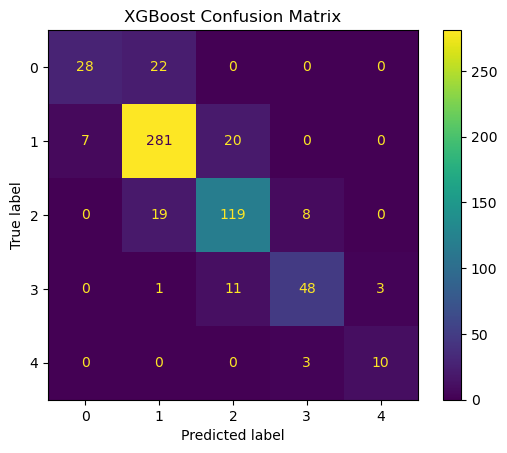

In [80]:
confusion=ConfusionMatrixDisplay(scores['XGBoost']['ConfusionMatrix'])
confusion.plot()
plt.title(f'XGBoost Confusion Matrix')
plt.show()

### XGBoost: log transformation on columns with >100 outliers

In [15]:
#function that iterates through specified columns to create histogram
def compare_distributions(df,column_name,selections,**kwargs): #function allows for additional arguments '**kwargs' so that one can include all options found in 'plt.hist()'
    #looping through each key/value pair from selections
    for label,selection in selections.items(): 
        _=plt.hist(df[selection][column_name],label=label,**kwargs) #plotting histogram of selected feature and column
    
    _=plt.legend() #inclusion of legend

#function that iterates through specified columns to create a scatterplot
def compare_scatter(df,x_var_name,y_var_name,selections,make_legend=True,**kwargs) :
    #looping through each key/value pair from selections
    for label,selection in selections.items():   
        _=plt.scatter(df[selection][x_var_name],df[selection][y_var_name],label=label,**kwargs) #scatterplot of each selection

    _=plt.xlabel(x_var_name) #labeling
    _=plt.ylabel(y_var_name)

    if make_legend:
        _=plt.legend() #inclusion of legend depending on whether 'make_legend' argument is true/false

In [ ]:
#pair plots
selection_dict={'< $100k':nums['Price Bins']=='< $100k',
                '$100k-$180k':nums['Price Bins']=='$100k-$180k',
                '$180k-$260k':nums['Price Bins']=='$180k-$260k',
                '$260k-$400k':nums['Price Bins']=='$260k-$400k',
                '> $400k':nums['Price Bins']=='> $400k'} #label/naming
column_names=nums.columns.to_list()
n_columns=len(column_names)
plt.figure(figsize=(100,100)) #setting up figure size

plot_i=0 #counter to allow for indexing for placement of subplots

#iterating and enumerating through variables
for i,x_var_name in enumerate(column_names):
    #another loop since plotting each variable against each other
    for j,y_var_name in enumerate(column_names):
        plot_i+=1 #increase counter for indexing
        plt.subplot(n_columns,n_columns,plot_i) #subplot layout is the number of features by number of features; 'plot_it' is the index
        make_legend = plot_i==1
        if i==j: #plots on the diagonal
            #plot histogram of feature instead of scatterplot of one feature against itself
            compare_distributions(nums,x_var_name,
                     selection_dict,
                     alpha=0.5,
                     density=1,
                     bins=50,
                     )
        else:
            #when not on the diagonal, plot the scatter plot
            compare_scatter(nums,x_var_name,y_var_name,selection_dict,make_legend=make_legend,alpha=0.5)


Please note that pairplot output was cleared to make file size smaller, allowing upload to GitHub.

In [17]:
outlier_cols=['Bsmt Half Bath','Kitchen AbvGr','Lot Frontage','Lot Area','Mas Vnr Area','BsmtFin SF 2','Total Bsmt SF','Open Porch SF','Enclosed Porch','Screen Porch','Misc Val']
log_nums=nums

#log transformation
for col in outlier_cols:
    log_nums[col]=np.log1p(log_nums[col]) #np.log1p used because of division by zero

In [18]:
#train/test split
log_X = log_nums.iloc[:,:-3] #excluding both target var
log_y = log_nums.iloc[:,-1:] #only categorical target var

#ordinal labeling of target variable
log_y=encoder.fit_transform(log_y)

X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(log_X, log_y, test_size=0.2,stratify=y,random_state=123)

#Model Training
XGB_log=xgb.XGBClassifier()
XGB_log.fit(X_train_log, y_train_log)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, objective='multi:softprob', ...)

In [19]:
#predictions
y_pred_log = XGB_log.predict(X_test_log)

#metrics; adding XGBoost scores to existing scores dictionary
scores['XGB Log']=dict()
scores['XGB Log']['Accuracy'] = accuracy_score(y_test_log, y_pred_log)
scores['XGB Log']['Precision'] = precision_score(y_test_log, y_pred_log,average='macro')
scores['XGB Log']['Recall'] = recall_score(y_test_log, y_pred_log,average='macro')
scores['XGB Log']['F1'] = f1_score(y_test_log, y_pred_log,average='macro')
scores['XGB Log']['ConfusionMatrix']=confusion_matrix(y_test_log,XGB_log.predict(X_test_log))

#table of metrics for previous models + XGB
display(HTML(tabulate.tabulate(list(map(lambda x: [x[0]]+x[1],zip(scores.keys(),map(lambda x: list(x.values()),scores.values())))), 
                               tablefmt='html',
                               headers=[" "]+list(next(iter(scores.items()))[1].keys()))))

,Accuracy,Precision,Recall,F1,ConfusionMatrix
XGBoost,0.837931,0.809218,0.763708,0.781929,[[ 28 22 0 0 0] [ 7 281 20 0 0] [ 0 19 119 8 0] [ 0 1 11 48 3] [ 0 0 0 3 10]]
XGB Log,0.837931,0.809218,0.763708,0.781929,[[ 28 22 0 0 0] [ 7 281 20 0 0] [ 0 19 119 8 0] [ 0 1 11 48 3] [ 0 0 0 3 10]]


### XGBoost: SMOTE (imbalance problem)

In [42]:
from imblearn.over_sampling import SMOTE

X_tr, X_ts, y_tr, y_ts = train_test_split(X, y, test_size=0.2,random_state=123)

smote=SMOTE()
X_train_smote, y_train_smote=smote.fit_resample(X_tr, y_tr) #using nums dataframe pre-Log Transformation

#Model Training
XGB_smote=xgb.XGBClassifier()
XGB_smote.fit(X_train_smote, y_train_smote)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, objective='multi:softprob', ...)

In [43]:
#predictions
y_pred_smote = XGB_smote.predict(X_ts)

#metrics; adding XGBoost scores to existing scores dictionary
scores['XGB SMOTE']=dict()
scores['XGB SMOTE']['Accuracy'] = accuracy_score(y_ts, y_pred_smote)
scores['XGB SMOTE']['Precision'] = precision_score(y_ts, y_pred_smote,average='macro')
scores['XGB SMOTE']['Recall'] = recall_score(y_ts, y_pred_smote,average='macro')
scores['XGB SMOTE']['F1'] = f1_score(y_ts, y_pred_smote,average='macro')
scores['XGB SMOTE']['ConfusionMatrix']=confusion_matrix(y_ts,XGB_smote.predict(X_ts))

#table of metrics for previous models + XGB
display(HTML(tabulate.tabulate(list(map(lambda x: [x[0]]+x[1],zip(scores.keys(),map(lambda x: list(x.values()),scores.values())))), 
                               tablefmt='html',
                               headers=[" "]+list(next(iter(scores.items()))[1].keys()))))

,Accuracy,Precision,Recall,F1,ConfusionMatrix
XGBoost,0.837931,0.809218,0.763708,0.781929,[[ 28 22 0 0 0] [ 7 281 20 0 0] [ 0 19 119 8 0] [ 0 1 11 48 3] [ 0 0 0 3 10]]
XGB Log,0.837931,0.809218,0.763708,0.781929,[[ 28 22 0 0 0] [ 7 281 20 0 0] [ 0 19 119 8 0] [ 0 1 11 48 3] [ 0 0 0 3 10]]
XGB SMOTE,0.812069,0.785212,0.789163,0.786395,[[ 37 16 1 0 0] [ 16 266 27 0 0] [ 0 21 100 9 0] [ 0 0 14 55 3] [ 0 0 0 2 13]]


XGBoost with SMOTE performed similarly based on F1 Score, but had a better prediction balance when looking at the Precision, Recall, and F1 scores together.

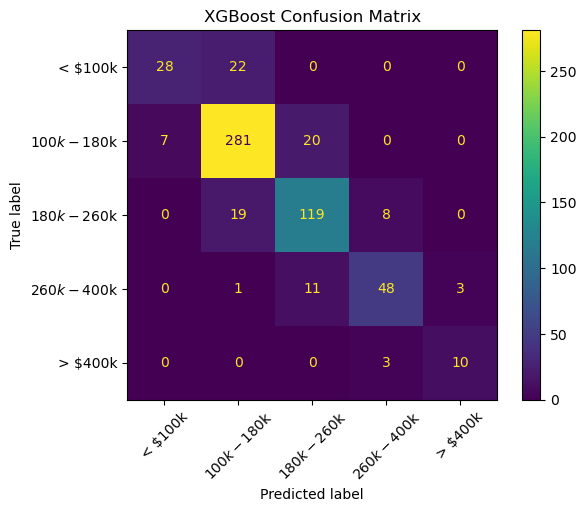

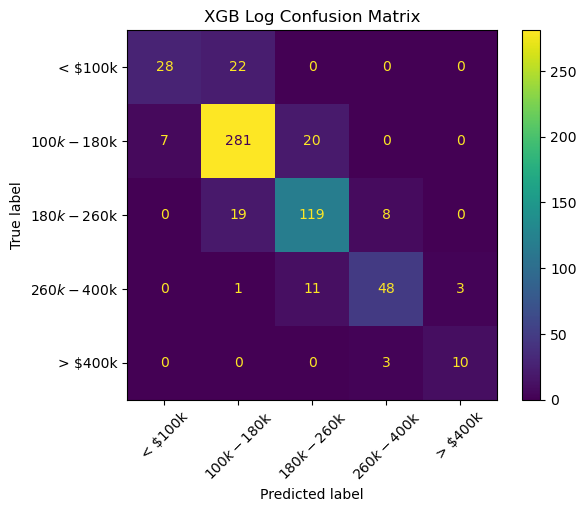

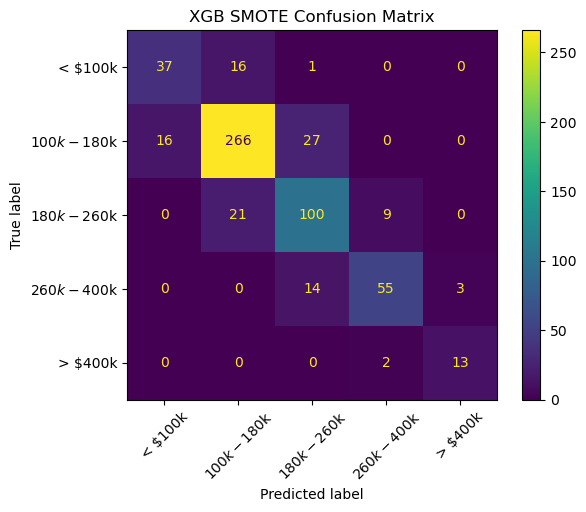

In [44]:
for cls_name in scores:
    confusion=ConfusionMatrixDisplay(scores[cls_name]['ConfusionMatrix'],display_labels=labels)
    confusion.plot()
    plt.title(f'{cls_name} Confusion Matrix')
    plt.xticks(rotation=45)

In [47]:
#saving XGBoost SMOTE model
XGB_smote.save_model("XGB_SMOTE.json")

In [74]:
print(classification_report(y_ts, y_pred_smote))

              precision    recall  f1-score   support

         0.0       0.70      0.69      0.69        54
         1.0       0.88      0.86      0.87       309
         2.0       0.70      0.77      0.74       130
         3.0       0.83      0.76      0.80        72
         4.0       0.81      0.87      0.84        15

    accuracy                           0.81       580
   macro avg       0.79      0.79      0.79       580
weighted avg       0.82      0.81      0.81       580



### Hyperparameter Tuning on XGBoost SMOTE Model

In [2]:
from sklearn.model_selection import cross_val_score, GridSearchCV

In [46]:
#Cross-Validation
cv_scores=cross_val_score(XGB_smote, X_train_smote, y_train_smote, cv=5, scoring='f1_macro')
print("Cross-Validation F1 Scores:", cv_scores)
print("Mean F1 Score:", cv_scores.mean())

Cross-Validation F1 Scores: [0.8847073  0.93162118 0.95166346 0.95459133 0.94598634]
Mean F1 Score: 0.9337139201235412


In [ ]:
#Hyperparameter Tuning
param_grid = {
    'n_estimators': [200, 400, 600, 800],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1, 0.3],
    'colsample_bytree': [0.7, 0.9, 1],
    'gamma': [0, 0.1, 0.3, 0.5],
    'reg_alpha': [0, 0.1, 0.5, 1],
    'reg_lambda': [1, 3, 5, 10]
}
grid_search = GridSearchCV(estimator=XGB_smote, param_grid=param_grid, cv=3, scoring='f1_macro', verbose=2)
grid_search.fit(X_train_smote, y_train_smote)
best_params = grid_search.best_params_
print("Best Hyperparameters:", best_params)

Fitting 3 folds for each of 12288 candidates, totalling 36864 fits
[CV] END colsample_bytree=0.7, gamma=0, learning_rate=0.01, max_depth=3, n_estimators=200, reg_alpha=0, reg_lambda=1; total time=   0.3s
[CV] END colsample_bytree=0.7, gamma=0, learning_rate=0.01, max_depth=3, n_estimators=200, reg_alpha=0, reg_lambda=1; total time=   0.3s
[CV] END colsample_bytree=0.7, gamma=0, learning_rate=0.01, max_depth=3, n_estimators=200, reg_alpha=0, reg_lambda=1; total time=   0.3s
[CV] END colsample_bytree=0.7, gamma=0, learning_rate=0.01, max_depth=3, n_estimators=200, reg_alpha=0, reg_lambda=3; total time=   0.3s
[CV] END colsample_bytree=0.7, gamma=0, learning_rate=0.01, max_depth=3, n_estimators=200, reg_alpha=0, reg_lambda=3; total time=   0.3s
[CV] END colsample_bytree=0.7, gamma=0, learning_rate=0.01, max_depth=3, n_estimators=200, reg_alpha=0, reg_lambda=3; total time=   0.3s
[CV] END colsample_bytree=0.7, gamma=0, learning_rate=0.01, max_depth=3, n_estimators=200, reg_alpha=0, reg_lam

In [49]:
#saving HT XGBoost SMOTE model
XGB_smote.save_model("XGB_SMOTE_HT.json")

In [51]:
# Obtaining the best performing model from the grid search results
best_model = grid_search.best_estimator_

# predictions
y_pred_ht = best_model.predict(X_ts)

#metrics; adding XGBoost scores to existing scores dictionary
scores['XGB SMOTE HT']=dict()
scores['XGB SMOTE HT']['Accuracy'] = accuracy_score(y_ts, y_pred_ht)
scores['XGB SMOTE HT']['Precision'] = precision_score(y_ts, y_pred_ht,average='macro')
scores['XGB SMOTE HT']['Recall'] = recall_score(y_ts, y_pred_ht,average='macro')
scores['XGB SMOTE HT']['F1'] = f1_score(y_ts, y_pred_ht,average='macro')
scores['XGB SMOTE HT']['ConfusionMatrix']=confusion_matrix(y_ts,best_model.predict(X_ts))

#table of metrics for previous models + XGB
display(HTML(tabulate.tabulate(list(map(lambda x: [x[0]]+x[1],zip(scores.keys(),map(lambda x: list(x.values()),scores.values())))), 
                               tablefmt='html',
                               headers=[" "]+list(next(iter(scores.items()))[1].keys()))))


,Accuracy,Precision,Recall,F1,ConfusionMatrix
XGBoost,0.837931,0.809218,0.763708,0.781929,[[ 28 22 0 0 0] [ 7 281 20 0 0] [ 0 19 119 8 0] [ 0 1 11 48 3] [ 0 0 0 3 10]]
XGB Log,0.837931,0.809218,0.763708,0.781929,[[ 28 22 0 0 0] [ 7 281 20 0 0] [ 0 19 119 8 0] [ 0 1 11 48 3] [ 0 0 0 3 10]]
XGB SMOTE,0.812069,0.785212,0.789163,0.786395,[[ 37 16 1 0 0] [ 16 266 27 0 0] [ 0 21 100 9 0] [ 0 0 14 55 3] [ 0 0 0 2 13]]
XGB SMOTE HT,0.801724,0.763272,0.772809,0.765381,[[ 36 18 0 0 0] [ 16 266 27 0 0] [ 0 23 99 8 0] [ 0 1 15 51 5] [ 0 0 0 2 13]]


### v2 Hyperparameter Tuning on XGBoost SMOTE Model

In [72]:
from imblearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report

In [56]:
pipeline=Pipeline([('smote', SMOTE(random_state=123)),('xgb', xgb.XGBClassifier())])
pipeline.fit(X_train, y_train)

Pipeline(steps=[('smote', SMOTE(random_state=123)),
                ('xgb',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric=None,
                               feature_types=None, gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None,
                               objective='multi:softprob', ...))])

In [57]:
#Cross-Validation
cv_scores2=cross_val_score(pipeline, X_train, y_train, cv=5, scoring='f1_macro')
print("Cross-Validation F1 Scores:", cv_scores2)
print("Mean F1 Score:", cv_scores2.mean())

Cross-Validation F1 Scores: [0.75150263 0.78893026 0.76770817 0.73142255 0.70958156]
Mean F1 Score: 0.749829035056086


In [62]:
#Hyperparameter Tuning
param_grid2 = {
    'xgb__n_estimators': [600, 800, 1000, 1200],
    'xgb__max_depth': [7, 9, 11, 13],
    'xgb__learning_rate': [0.01, 0.05, 0.1, 0.3],
    'xgb__colsample_bytree': [0.7, 0.9, 1],
    'xgb__gamma': [0, 0.1, 0.3, 0.5],
    'xgb__reg_alpha': [0, 0.1, 0.5, 1],
    'xgb__reg_lambda': [1, 3, 5, 10]
}
grid_search2 = RandomizedSearchCV(pipeline, param_grid2, cv=5, scoring='f1_macro', n_iter=40, verbose=2)
grid_search2.fit(X_train, y_train)
best_params2 = grid_search2.best_params_
print("Best Hyperparameters:", best_params2)

Fitting 5 folds for each of 40 candidates, totalling 200 fits
[CV] END xgb__colsample_bytree=0.7, xgb__gamma=0.3, xgb__learning_rate=0.3, xgb__max_depth=11, xgb__n_estimators=800, xgb__reg_alpha=0.5, xgb__reg_lambda=5; total time=   0.7s
[CV] END xgb__colsample_bytree=0.7, xgb__gamma=0.3, xgb__learning_rate=0.3, xgb__max_depth=11, xgb__n_estimators=800, xgb__reg_alpha=0.5, xgb__reg_lambda=5; total time=   0.8s
[CV] END xgb__colsample_bytree=0.7, xgb__gamma=0.3, xgb__learning_rate=0.3, xgb__max_depth=11, xgb__n_estimators=800, xgb__reg_alpha=0.5, xgb__reg_lambda=5; total time=   0.6s
[CV] END xgb__colsample_bytree=0.7, xgb__gamma=0.3, xgb__learning_rate=0.3, xgb__max_depth=11, xgb__n_estimators=800, xgb__reg_alpha=0.5, xgb__reg_lambda=5; total time=   0.6s
[CV] END xgb__colsample_bytree=0.7, xgb__gamma=0.3, xgb__learning_rate=0.3, xgb__max_depth=11, xgb__n_estimators=800, xgb__reg_alpha=0.5, xgb__reg_lambda=5; total time=   0.7s
[CV] END xgb__colsample_bytree=0.7, xgb__gamma=0.3, xgb__l

In [64]:
#saving v2 HT XGBoost SMOTE model
XGB_smote.save_model("XGB_SMOTE_HTv2.json")

In [76]:
# Obtaining the best performing model from the grid search results
best_model2 = grid_search2.best_estimator_

# predictions
y_pred_htv2 = best_model2.predict(X_test)

#metrics; adding XGBoost scores to existing scores dictionary
scores['XGB SMOTE HT v2']=dict()
scores['XGB SMOTE HT v2']['Accuracy'] = accuracy_score(y_test, y_pred_htv2)
scores['XGB SMOTE HT v2']['Precision'] = precision_score(y_test, y_pred_htv2,average='macro')
scores['XGB SMOTE HT v2']['Recall'] = recall_score(y_test, y_pred_htv2,average='macro')
scores['XGB SMOTE HT v2']['F1'] = f1_score(y_test, y_pred_htv2,average='macro')
scores['XGB SMOTE HT v2']['ConfusionMatrix']=confusion_matrix(y_test,best_model2.predict(X_test))

#table of metrics for previous models + XGB
display(HTML(tabulate.tabulate(list(map(lambda x: [x[0]]+x[1],zip(scores.keys(),map(lambda x: list(x.values()),scores.values())))), 
                               tablefmt='html',
                               headers=[" "]+list(next(iter(scores.items()))[1].keys()))))


,Accuracy,Precision,Recall,F1,ConfusionMatrix
XGBoost,0.837931,0.809218,0.763708,0.781929,[[ 28 22 0 0 0] [ 7 281 20 0 0] [ 0 19 119 8 0] [ 0 1 11 48 3] [ 0 0 0 3 10]]
XGB Log,0.837931,0.809218,0.763708,0.781929,[[ 28 22 0 0 0] [ 7 281 20 0 0] [ 0 19 119 8 0] [ 0 1 11 48 3] [ 0 0 0 3 10]]
XGB SMOTE,0.812069,0.785212,0.789163,0.786395,[[ 37 16 1 0 0] [ 16 266 27 0 0] [ 0 21 100 9 0] [ 0 0 14 55 3] [ 0 0 0 2 13]]
XGB SMOTE HT,0.801724,0.763272,0.772809,0.765381,[[ 36 18 0 0 0] [ 16 266 27 0 0] [ 0 23 99 8 0] [ 0 1 15 51 5] [ 0 0 0 2 13]]
XGB SMOTE HT v2,0.824138,0.744132,0.750431,0.746208,[[ 33 17 0 0 0] [ 13 273 22 0 0] [ 0 15 119 12 0] [ 0 1 12 44 6] [ 0 0 0 4 9]]
XGB SMOTE v2,0.825862,0.74311,0.734799,0.737965,[[ 32 18 0 0 0] [ 11 276 21 0 0] [ 0 16 118 12 0] [ 0 1 11 45 6] [ 0 0 0 5 8]]


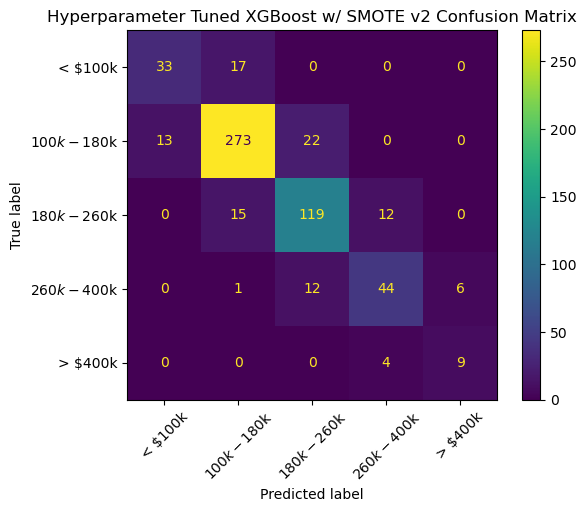

In [79]:
confusion=ConfusionMatrixDisplay(scores['XGB SMOTE HT v2']['ConfusionMatrix'],display_labels=labels)
confusion.plot()
plt.title(f'Hyperparameter Tuned XGBoost w/ SMOTE v2 Confusion Matrix')
plt.xticks(rotation=45)
plt.show()

In [71]:
print(classification_report(y_test, y_pred_htv2))

              precision    recall  f1-score   support

         0.0       0.72      0.66      0.69        50
         1.0       0.89      0.89      0.89       308
         2.0       0.78      0.82      0.80       146
         3.0       0.73      0.70      0.72        63
         4.0       0.60      0.69      0.64        13

    accuracy                           0.82       580
   macro avg       0.74      0.75      0.75       580
weighted avg       0.82      0.82      0.82       580



### Retesting base XGBoost model w/ SMOTE

In [78]:
#predictions
y_pred_smote2 = pipeline.predict(X_test)

#metrics; adding XGBoost scores to existing scores dictionary
scores['XGB SMOTE v2']=dict()
scores['XGB SMOTE v2']['Accuracy'] = accuracy_score(y_test, y_pred_smote2)
scores['XGB SMOTE v2']['Precision'] = precision_score(y_test, y_pred_smote2,average='macro')
scores['XGB SMOTE v2']['Recall'] = recall_score(y_test, y_pred_smote2,average='macro')
scores['XGB SMOTE v2']['F1'] = f1_score(y_test, y_pred_smote2,average='macro')
scores['XGB SMOTE v2']['ConfusionMatrix']=confusion_matrix(y_test,pipeline.predict(X_test))

#table of metrics for previous models + XGB
display(HTML(tabulate.tabulate(list(map(lambda x: [x[0]]+x[1],zip(scores.keys(),map(lambda x: list(x.values()),scores.values())))), 
                               tablefmt='html',
                               headers=[" "]+list(next(iter(scores.items()))[1].keys()))))

,Accuracy,Precision,Recall,F1,ConfusionMatrix
XGBoost,0.837931,0.809218,0.763708,0.781929,[[ 28 22 0 0 0] [ 7 281 20 0 0] [ 0 19 119 8 0] [ 0 1 11 48 3] [ 0 0 0 3 10]]
XGB Log,0.837931,0.809218,0.763708,0.781929,[[ 28 22 0 0 0] [ 7 281 20 0 0] [ 0 19 119 8 0] [ 0 1 11 48 3] [ 0 0 0 3 10]]
XGB SMOTE,0.812069,0.785212,0.789163,0.786395,[[ 37 16 1 0 0] [ 16 266 27 0 0] [ 0 21 100 9 0] [ 0 0 14 55 3] [ 0 0 0 2 13]]
XGB SMOTE HT,0.801724,0.763272,0.772809,0.765381,[[ 36 18 0 0 0] [ 16 266 27 0 0] [ 0 23 99 8 0] [ 0 1 15 51 5] [ 0 0 0 2 13]]
XGB SMOTE HT v2,0.824138,0.744132,0.750431,0.746208,[[ 33 17 0 0 0] [ 13 273 22 0 0] [ 0 15 119 12 0] [ 0 1 12 44 6] [ 0 0 0 4 9]]
XGB SMOTE v2,0.825862,0.74311,0.734799,0.737965,[[ 32 18 0 0 0] [ 11 276 21 0 0] [ 0 16 118 12 0] [ 0 1 11 45 6] [ 0 0 0 5 8]]


In [75]:
print(classification_report(y_test, y_pred_smote2))

              precision    recall  f1-score   support

         0.0       0.74      0.64      0.69        50
         1.0       0.89      0.90      0.89       308
         2.0       0.79      0.81      0.80       146
         3.0       0.73      0.71      0.72        63
         4.0       0.57      0.62      0.59        13

    accuracy                           0.83       580
   macro avg       0.74      0.73      0.74       580
weighted avg       0.83      0.83      0.83       580



In [86]:
scores_file=pd.DataFrame.from_dict(scores,orient='index')
scores_file.to_csv('cap2_metrics.csv')